## Basic Setup

In [1]:
import os
import sys
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from keras.layers import Dense, Flatten, Input, Dropout, BatchNormalization
from keras.models import Sequential, Model
from keras.regularizers import l2

/Users/peterthyssen/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# Set the base path to the directory where src is located
base_path = '/Users/peterthyssen/Documents/GitHub/cbs-mldl-drowsiness-detection'

# Change the current working directory
os.chdir(base_path)

# Add the src directory to the system path
src_path = os.path.join(base_path, 'src')
sys.path.append(src_path)

# Now you can import the modules
from src.utils import load_and_preprocess_images, plot_images
from src.model_evaluation import evaluate_model, plot_history, plot_predictions

In [3]:
# set the random seeds to make sure that the results are reproducible
SEED = 1234
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)

In [6]:
model_name = '2_Finetuned_mlp'
repo_path = '/Users/peterthyssen/Documents/Repositories/cbs-mldl-drowsiness-detection'

syntheticDataPath = repo_path + '/data/Unity_Data_Test_Train'
syntheticTrainingPath = syntheticDataPath + '/TrainingSet'
syntheticTestPath = syntheticDataPath + '/TestSet'

realDataPath = repo_path + '/data/CEW_Data_Test_Train'
realTrainingPath = realDataPath + '/TrainingSet'
realTestPath = realDataPath + '/TestSet'

In [7]:
comment = "mlp_v14_07_24c"
model_file_path = repo_path + f"/models/{model_name}/weights/{comment}_model.keras"
ckpt_file_path = repo_path + f"/models/{model_name}/ckpt/{comment}_checkpoint.model.keras"
history_file_path = repo_path + f"/models/{model_name}/history/{comment}_history.csv"
assert not os.path.exists(ckpt_file_path), "Model already exists. Please change the comment."

In [8]:
# Hyperparameters
BATCH_SIZE = 64
IMAGE_SIZE = (224, 224)
INPUT_SHAPE = IMAGE_SIZE + (3,)

DATA_AUG_RATE = 0.1
EPOCHS = 100
REGULARIZATION = 0.01
DROPOUT = 0.3
LEARNING_RATE = 0.0001
LOSS_FUNCTION = 'binary_crossentropy'
OPTIMIZER = 'adam'

In [9]:
early_stop = EarlyStopping(monitor="val_accuracy", mode="max", patience=20, start_from_epoch=10)
checkpoint = ModelCheckpoint(ckpt_file_path, monitor="val_accuracy", mode="max", save_best_only=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=10, min_lr=0.00001, verbose=1)

In [10]:
real_train_data = load_and_preprocess_images(realTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, data_aug_rate=DATA_AUG_RATE, subset='training', validation_split=0.2)
real_valid_data = load_and_preprocess_images(realTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, subset='validation', validation_split=0.2)
real_test_data = load_and_preprocess_images(realTestPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, shuffle=False)

Found 3876 files belonging to 2 classes.
Using 3101 files for training.
Found 3876 files belonging to 2 classes.
Using 775 files for validation.
Found 970 files belonging to 2 classes.


In [11]:
synth_train_data = load_and_preprocess_images(syntheticTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, data_aug_rate=DATA_AUG_RATE, subset='training', validation_split=0.2)
synth_valid_data = load_and_preprocess_images(syntheticTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, subset='validation', validation_split=0.2)
synth_test_data = load_and_preprocess_images(syntheticTestPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, shuffle=False)

Found 4743 files belonging to 2 classes.
Using 3795 files for training.
Found 4743 files belonging to 2 classes.
Using 948 files for validation.
Found 1187 files belonging to 2 classes.


In [12]:
# Define the MLP model
def build_mlp_model(input_shape):
    model = Sequential([
        Flatten(input_shape=input_shape),
        Dense(128, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    return model

# Build the model
model = build_mlp_model(INPUT_SHAPE)

# Define the path to the pre-trained model weights
pretrained_model_path = '/Users/peterthyssen/Documents/Repositories/cbs-mldl-drowsiness-detection/models/1_synthetic_mlp/weights/mlp_v14_07_24b_model.keras'

# Load pre-trained weights
model.load_weights(pretrained_model_path)

# Compile the model
model.compile(optimizer=OPTIMIZER, loss=LOSS_FUNCTION, metrics=['accuracy'])

# Print model summary to verify
model.summary()

/Users/peterthyssen/anaconda3/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    19,267,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,267,841 (73.50 MB)

 Trainable params: 19,267,841 (73.50 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(
    real_train_data,
    validation_data=real_valid_data,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint, reduce_lr]
    )

Epoch 1/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - accuracy: 0.5623 - loss: 31.0114
Epoch 1: val_accuracy improved from -inf to 0.69806, saving model to /Users/peterthyssen/Documents/Repositories/cbs-mldl-drowsiness-detection/models/2_Finetuned_mlp/ckpt/mlp_v14_07_24c_checkpoint.model.keras
49/49 ━━━━━━━━━━━━━━━━━━━━ 20s 404ms/step - accuracy: 0.5630 - loss: 30.6914 - val_accuracy: 0.6981 - val_loss: 2.4432 - learning_rate: 0.0010
Epoch 2/100
48/49 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.7121 - loss: 2.7891
Epoch 2: val_accuracy improved from 0.69806 to 0.71484, saving model to /Users/peterthyssen/Documents/Repositories/cbs-mldl-drowsiness-detection/models/2_Finetuned_mlp/ckpt/mlp_v14_07_24c_checkpoint.model.keras
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.7119 - loss: 2.7792 - val_accuracy: 0.7148 - val_loss: 1.9991 - learning_rate: 0.0010
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7253 - loss: 1.8350
Epoch 3: val_accuracy improved from 0.

In [15]:
# Ensure the directory exists
os.makedirs(os.path.dirname(history_file_path), exist_ok=True)

# save the history
history_df = pd.DataFrame(history.history)
history_df['epoch'] = history.epoch
history_df.to_csv(history_file_path, index=False)

In [16]:
# load the best model
model.load_weights(ckpt_file_path)

In [17]:
# Ensure the directory exists
os.makedirs(os.path.dirname(model_file_path), exist_ok=True)

# save the model
model.save(model_file_path)

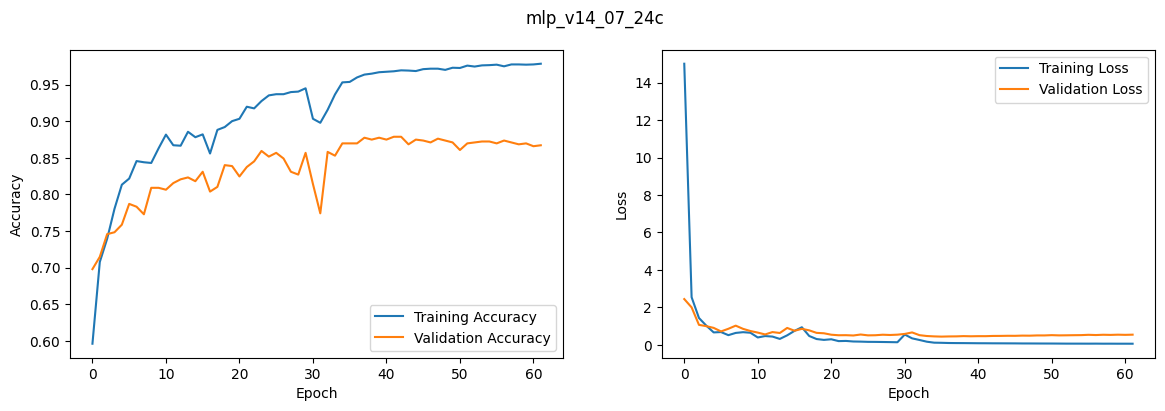

Best train_accuracy: 0.9784
Best train_loss: 0.058
Best val_accuracy: 0.8787
Best val_loss: 0.4376
Last improvement at epoch: 42


In [18]:
plot_history(comment, history)

In [19]:
evaluate_model(model, real_test_data)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8733 - loss: 0.4433
Test loss: 0.4110649824142456
Test accuracy: 0.8814433217048645
